# Atividade 6 - Planejamento

## Enunciado: 

---
### Problema 1
Um fiscal de agência de seguro avalia os valores de Prêmios cobrado por uma seguradora em 6 cidades. As cidades possuem duas características:
- **A = Tamanho** (Pequena, Média, Grande)  
- **B = Região** (Norte, Sul)

| Tamanho/Região | Norte | Sul |
|----------------|-------|-----|
| Pequena        | 140   | 100 |
| Média          | 210   | 180 |
| Grande         | 220   | 220 |

- **item a:** Faça análise completa dos dados do problema.  
- **item b:** Use o teste de aditividade de Tukey para verificar a interação.  
- **item c:** Caso positivo, use o modelo de regressão para elaborar a análise.

---

## Análise Completa

### Estrutura Experimental

Trata-se de um experimento **fatorial 3 × 2 sem replicação**, em que:
- **Fator A** = Tamanho da cidade (Pequena, Média, Grande) — $a = 3$ níveis  
- **Fator B** = Região (Norte, Sul) — $b = 2$ níveis  
- **Variável resposta**: Prêmio cobrado (em unidades monetárias)

Como há apenas **uma observação por tratamento**, não é possível estimar a interação diretamente a partir da ANOVA — a SSE seria 0, a SS da interação seria o novo SSE.
Por isso, o modelo assumido inicialmente é o **modelo aditivo**:

$$Y_{ij} = \mu + \alpha_i + \beta_j + \varepsilon_{ij}$$

onde:
- $Y_{ij}$: prêmio observado no nível $i$ do Tamanho e $j$ da Região  
- $\mu$: média geral  
- $\alpha_i$: efeito do nível $i$ do Fator A (Tamanho), com $\sum \alpha_i = 0$  
- $\beta_j$: efeito do nível $j$ do Fator B (Região), com $\sum \beta_j = 0$  
- $\varepsilon_{ij} \sim N(0,\sigma^2)$: erro aleatório

### Hipóteses

**Para o Fator A (Tamanho):**

$$H_0: \alpha_1 = \alpha_2 = \alpha_3 = 0$$
$$H_1: \text{Pelo menos um } \alpha_i \neq 0$$

**Para o Fator B (Região):**

$$H_0: \beta_1 = \beta_2 = 0$$
$$H_1: \text{Pelo menos um } \beta_j \neq 0$$

### Item a — Análise Completa

#### a.1 Estatística descritiva

In [62]:
# Entrada dos dados
premio <- c(140, 100,
            210, 180,
            220, 220)

tamanho <- factor(rep(c("Pequena", "Media", "Grande"), each = 2),
                  levels = c("Pequena", "Media", "Grande"))
regiao  <- factor(rep(c("Norte", "Sul"), times = 3),
                  levels = c("Norte", "Sul"))

dados1 <- data.frame(Tamanho = tamanho, Regiao = regiao, Premio = premio)
print(dados1)

  Tamanho Regiao Premio
1 Pequena  Norte    140
2 Pequena    Sul    100
3   Media  Norte    210
4   Media    Sul    180
5  Grande  Norte    220
6  Grande    Sul    220


In [63]:
library(dplyr)

# Estatísticas por Tamanho (Fator A)
dados1 %>%
  group_by(Tamanho) %>%
  summarise(Media = mean(Premio), DP = sd(Premio), n = n())

Tamanho,Media,DP,n
<fct>,<dbl>,<dbl>,<int>
Pequena,120,28.28427,2
Media,195,21.21320,2
Grande,220,0.00000,2


In [64]:
# Estatísticas por Região (Fator B)
dados1 %>%
  group_by(Regiao) %>%
  summarise(Media = mean(Premio), DP = sd(Premio), n = n())

Regiao,Media,DP,n
<fct>,<dbl>,<dbl>,<int>
Norte,190.0000,43.58899,3
Sul,166.6667,61.10101,3


#### a.2 Gráficos exploratórios

O gráfico de perfis de médias é especialmente útil para inspecionar visualmente a presença de interação: se as linhas forem paralelas, o modelo aditivo é adequado; caso contrário, há indício de interação.

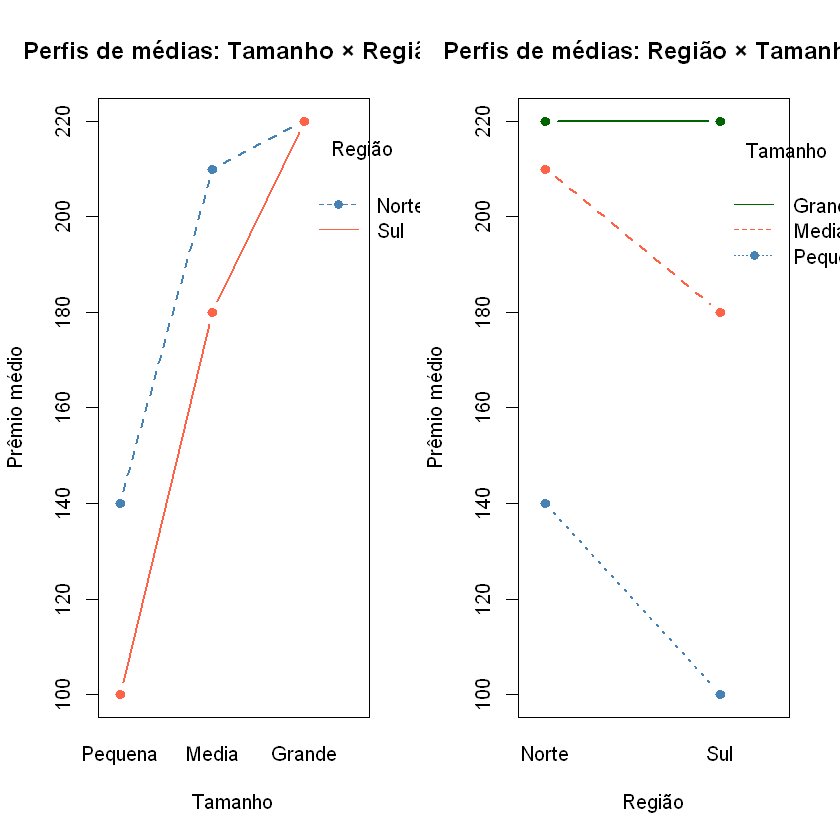

In [65]:
par(mfrow = c(1, 2))

# Gráfico de interação: Tamanho × Região
interaction.plot(dados1$Tamanho, dados1$Regiao, dados1$Premio,
                 type = "b", col = c("steelblue", "tomato"), lwd = 2, pch = 19,
                 xlab = "Tamanho", ylab = "Prêmio médio",
                 trace.label = "Região",
                 main = "Perfis de médias: Tamanho × Região")

# Gráfico de interação invertido: Região × Tamanho
interaction.plot(dados1$Regiao, dados1$Tamanho, dados1$Premio,
                 type = "b", col = c("steelblue", "tomato", "darkgreen"),
                 lwd = 2, pch = 19,
                 xlab = "Região", ylab = "Prêmio médio",
                 trace.label = "Tamanho",
                 main = "Perfis de médias: Região × Tamanho")

par(mfrow = c(1, 1))

Os perfis de médias apresentam linhas visualmente mais ou menos próximas do paralelismo, sugerindo ligeiramente a ausência de interação — mas isso será testado formalmente pelo teste de Tukey (item b).

---

#### a.3 Ajuste do Modelo Aditivo e ANOVA

O modelo é ajustado conforme dito anteriormente:

$$Y_{ij} = \mu + \alpha_i + \beta_j + \varepsilon_{ij}$$

In [66]:
# Ajuste do modelo aditivo (sem interação — experimento sem replicação)
modelo1 <- aov(Premio ~ Tamanho + Regiao, data = dados1)
summary(modelo1)

            Df Sum Sq Mean Sq F value Pr(>F)  
Tamanho      2  10833    5417  25.000 0.0385 *
Regiao       1    817     817   3.769 0.1917  
Residuals    2    433     217                 
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

#### Verificação dos Pressupostos

Com apenas 6 observações e 2 graus de liberdade residual, os testes têm pouca potência, mas são realizados por completude.

In [67]:
library(car)

residuos1  <- residuals(modelo1)
ajustados1 <- fitted(modelo1)
# Teste de Shapiro-Wilk (normalidade)
shapiro.test(residuos1)


	Shapiro-Wilk normality test

data:  residuos1
W = 0.94813, p-value = 0.7251


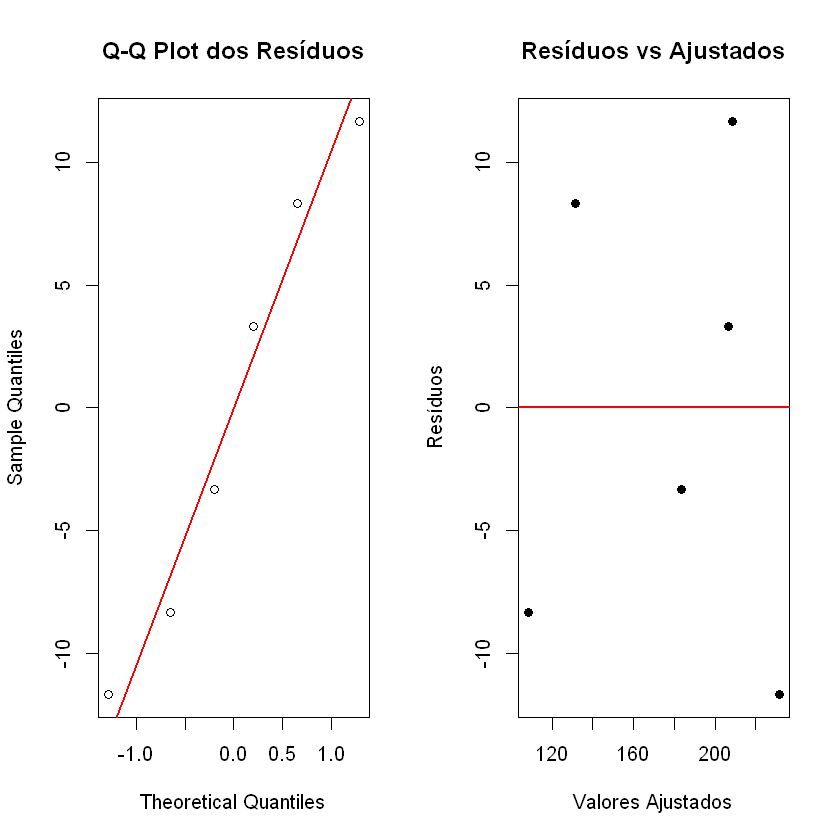

In [68]:
par(mfrow = c(1, 2))

# Q-Q Plot
qqnorm(residuos1, main = "Q-Q Plot dos Resíduos")
qqline(residuos1, col = "red", lwd = 2)

# Resíduos vs Ajustados
plot(ajustados1, residuos1,
     xlab = "Valores Ajustados", ylab = "Resíduos",
     main = "Resíduos vs Ajustados", pch = 19)
abline(h = 0, col = "red", lwd = 2)

par(mfrow = c(1, 1))

#### Interpretação da ANOVA

Com base na tabela ANOVA:

- **Fator A (Tamanho):** Valor-p = 0.0385, rejeita-se $H_0$ ao nível de 5%, concluindo que o tamanho da cidade influencia significativamente o prêmio cobrado.  
- **Fator B (Região):** Valor-p = 0.1917,$H_0$ não rejeitada, a região da cidade não influencia significamente o prêmio cobrado.

Como não há replicação, a interação $AB$ não é estimada diretamente — ela seria confundida com o erro. O teste formal de interação é o de Tukey, realizado no item b.

---

### Item b — Teste de Aditividade de Tukey

O **teste de aditividade de Tukey (1949)** avalia formalmente se a interação $AB$ é nula no modelo sem replicação. A ideia é decompor a SS do resíduo em uma componente atribuível à interação (1 g.l.) e o restante.

A estatística é baseada em:

$$SS_{\text{interação}} = \frac{\left(\sum_{i,j} y_{ij}\, \hat{\alpha}_i\, \hat{\beta}_j\right)^2}{SS_A \cdot SS_B / SS_T}$$

que segue uma distribuição F com 1 e ab - (a+b) graus de liberdade,

onde $\hat{\alpha}_i = \bar{y}_{i.} - \bar{y}_{..}$ e $\hat{\beta}_j = \bar{y}_{.j} - \bar{y}_{..}$.

As hipóteses são:

$$H_0: \text{não há interação (modelo aditivo é adequado)}$$
$$H_1: \text{existe interação não-aditiva}$$

In [69]:
# ── Teste de Aditividade de Tukey (implementação manual) ──────────────────────

Y <- matrix(dados1$Premio, nrow = 3, ncol = 2,
            dimnames = list(c("Pequena","Media","Grande"), c("Norte","Sul")))

a <- nrow(Y)   # 3 níveis de Tamanho
b <- ncol(Y)   # 2 níveis de Região

media_geral  <- mean(Y)
media_linha  <- rowMeans(Y)         # médias por Tamanho
media_coluna <- colMeans(Y)         # médias por Região

# efeitos estimados
alpha_hat <- media_linha  - media_geral
beta_hat  <- media_coluna - media_geral

cat("Média geral:", media_geral, "\n")
cat("Efeitos de Tamanho (alpha_hat):\n"); print(alpha_hat)
cat("Efeitos de Região (beta_hat):\n");  print(beta_hat)

Média geral: 178.3333 
Efeitos de Tamanho (alpha_hat):
  Pequena     Media    Grande 
-18.33333 -18.33333  36.66667 
Efeitos de Região (beta_hat):
    Norte       Sul 
-28.33333  28.33333 


In [70]:
# Numerador da estatística de Tukey
num <- sum(outer(alpha_hat, beta_hat) * Y)^2

# SQA e SQB (usadas no denominador)
SQA <- b * sum(alpha_hat^2)
SQB <- a * sum(beta_hat^2)

# SS_interação (1 g.l.)
SS_inter <- num / (SQA * SQB)

# SS_resíduo total e SS_residuo puro (após retirar interação)
SS_res_total <- sum((Y - outer(media_linha, rep(1,b)) -
                         outer(rep(1,a), media_coluna) +
                         media_geral)^2)

SS_res_puro <- SS_res_total - SS_inter

cat("\nSS_interação (1 g.l.) =", round(SS_inter, 4), "\n")
cat("SS_resíduo total      =", round(SS_res_total, 4), "\n")
cat("SS_resíduo puro       =", round(SS_res_puro, 4), "\n")

# Estatística F
gl_res_puro <- (a - 1) * (b - 1) - 1
F_tukey <- (SS_inter / 1) / (SS_res_puro / gl_res_puro)
p_tukey  <- pf(F_tukey, df1 = 1, df2 = gl_res_puro, lower.tail = FALSE)

cat("\nF_Tukey =", round(F_tukey, 4),
    " | g.l. = 1 e", gl_res_puro,
    " | valor-p =", round(p_tukey, 4), "\n")


SS_interação (1 g.l.) = 272.2222 
SS_resíduo total      = 3233.333 
SS_resíduo puro       = 2961.111 

F_Tukey = 0.0919  | g.l. = 1 e 1  | valor-p = 0.8126 


#### Interpretação do Teste de Aditividade de Tukey

- **Valor-p =  0.8126**: é grande, não há evidência de interação — o modelo aditivo é adequado e o item c não é necessário.  

---


### Problema 2

Um hormônio de crescimento sintético é administrado em crianças com deficiência em produção desse hormônio. A variável resposta é a **diferença entre as taxas de crescimento** (antes e depois do uso).O pesquisador tem interesse em avaliar o efeito do **sexo** e do **grau de desenvolvimento ósseo**(Severo, moderado, leve). Em cada grupo, 3 crianças foram aleatoriamente alocadas. Porém 4 familias desistiram do experimento.


| **Sexo/Grau** | **Severo**          | **Moderado**        | **Leve**            |
|-----------|-----------------|-----------------|-----------------|
| Masculino | 1.4 ($Y_{111}$) <br> 2.4 ($Y_{112}$) <br> 2.2 ($Y_{113}$) | 2.1 ($Y_{121}$) <br> 1.7 ($Y_{122}$)     | 0.7 ($Y_{131}$) <br> 1.1 ($Y_{132}$)      |
| Feminino  | 2.4 ($Y_{211}$)            | 2.5 ($Y_{221}$) <br> 1.8 ($Y_{222}$) <br> 2.0 ($Y_{223}$) | 0.5($Y_{231}$) <br> 0.9 ($Y_{232}$) <br> 1.3 ($Y_{233}$)  |

item: faça análise completa desses dados

---

## Problema 2 — Análise Completa

### Estrutura Experimental

Este é um experimento **fatorial 2 × 3 com dados desbalanceados**, com:
- **Fator A** = Sexo (Masculino, Feminino) — $a = 2$ níveis  
- **Fator B** = Grau de desenvolvimento ósseo (Severo, Moderado, Leve) — $b = 3$ níveis  
- **Variável resposta**: Diferença na taxa de crescimento

O modelo usado seria:

$$Y_{ijk} = \mu + \alpha_i + \beta_j + (\alpha\beta)_{ij} + \varepsilon_{ijk}$$

onde:
- $Y_{ijk}$: $k$-ésima observação no nível $i$ de Sexo e nível $j$ de Grau  
- $\mu$: média geral  
- $\alpha_i$: efeito do $i$-ésimo nível de Sexo  
- $\beta_j$: efeito do $j$-ésimo nível de Grau  
- $(\alpha\beta)_{ij}$: efeito da interação  
- $\varepsilon_{ijk} \sim N(0, \sigma^2)$: erro aleatório

### Hipóteses seriam

**Para a Interação AB:**

$$H_0: (\alpha\beta)_{ij} = 0 \quad \forall i,j$$
$$H_1: \text{Pelo menos uma interação} \neq 0$$

**Para o Fator A (Sexo):**

$$H_0: \alpha_1 = \alpha_2 = 0 \qquad H_1: \text{Pelo menos um } \alpha_i \neq 0$$

**Para o Fator B (Grau):**

$$H_0: \beta_1 = \beta_2 = \beta_3 = 0 \qquad H_1: \text{Pelo menos um } \beta_j \neq 0$$

### Mas os dados são desbalancedos. Saída: Modelo de Regressão
---
### Modelo

$$Y_{ijk} = \mu + \alpha_2 X_2 + \beta_2 Z_2 + \beta_3 Z_3 + \gamma_{22} X_2 Z_2  + \gamma_{23} X_2 Z_3 + \varepsilon_{ijk}$$

Com as codificações *dummy* (referência: Masculino e Severo):

| Variável | Significado |
|----------|-------------|
| $X_2$    | 1 se Feminino, 0 c.c. |
| $Z_2$    | 1 se Moderado, 0 c.c. |
| $Z_3$    | 1 se Leve, 0 c.c.     |
| $X_2 Z_2$ | interação Feminino × Moderado |
| $X_2 Z_3$ | interação Feminino × Leve     |

*Set to zero*: $\alpha_1 = \alpha_{\text{Masculino}} = 0$, $\beta_1 = \beta_{\text{Severo}} = 0$ (categorias de referência).

O vetor de parâmetros é:
$$\boldsymbol{\beta} = (\mu,\; \alpha_2,\; \beta_2,\; \beta_3,\; \gamma_{22},\; \gamma_{23})^\top$$

In [71]:
# Os dados já foram criados anteriormente; recriamos aqui por completude
taxa <- c(1.4, 2.4, 2.2,   # Masc - Severo
          2.1, 1.7,         # Masc - Moderado
          0.7, 1.1,         # Masc - Leve
          2.4,              # Fem  - Severo
          2.5, 1.8, 2.0,   # Fem  - Moderado
          0.5, 0.9, 1.3)   # Fem  - Leve

sexo <- factor(c(rep("Masculino", 7), rep("Feminino", 7)))
grau <- factor(c(rep("Severo",3), rep("Moderado",2), rep("Leve",2),
                 rep("Severo",1), rep("Moderado",3), rep("Leve",3)),
               levels = c("Severo","Moderado","Leve"))

dados2 <- data.frame(Sexo = sexo, Grau = grau, Taxa = taxa)

# ── Dummies manuais (referência: Masculino e Severo) ──────────────────────────
dados2$Fem       <- as.numeric(dados2$Sexo == "Feminino")
dados2$Moderado  <- as.numeric(dados2$Grau == "Moderado")
dados2$Leve      <- as.numeric(dados2$Grau == "Leve")

# Termos de interação
dados2$Fem_Mod  <- dados2$Fem * dados2$Moderado
dados2$Fem_Leve <- dados2$Fem * dados2$Leve

dados2$Taxa <- taxa
print(dados2)

        Sexo     Grau Taxa Fem Moderado Leve Fem_Mod Fem_Leve
1  Masculino   Severo  1.4   0        0    0       0        0
2  Masculino   Severo  2.4   0        0    0       0        0
3  Masculino   Severo  2.2   0        0    0       0        0
4  Masculino Moderado  2.1   0        1    0       0        0
5  Masculino Moderado  1.7   0        1    0       0        0
6  Masculino     Leve  0.7   0        0    1       0        0
7  Masculino     Leve  1.1   0        0    1       0        0
8   Feminino   Severo  2.4   1        0    0       0        0
9   Feminino Moderado  2.5   1        1    0       1        0
10  Feminino Moderado  1.8   1        1    0       1        0
11  Feminino Moderado  2.0   1        1    0       1        0
12  Feminino     Leve  0.5   1        0    1       0        1
13  Feminino     Leve  0.9   1        0    1       0        1
14  Feminino     Leve  1.3   1        0    1       0        1


In [72]:
tapply(dados2$Taxa, list(dados2$Sexo, dados2$Grau), mean)

,Severo,Moderado,Leve
Feminino,2.4,2.1,0.9
Masculino,2.0,1.9,0.9


#### Médias de cada tratamento

| **Sexo/Grau** | **Severo**  | **Moderado**    | **Leve**        |
|-----------|-----------------|-----------------|-----------------|
| Masculino |     2.0         |     1.9         |   0.9           |
| Feminino  |        2.4      |         2.1     |      0.9        |

### 2.1 Ajuste do modelo de regressão

O modelo completo com interação é ajustado confoeme dito acima, via `lm()`. Note que o R com default já usa a codificação de referência — ao criar as dummies manualmente temos controle total sobre qual categoria é a referência.

In [73]:
# Modelo completo com dummies manuais
mod_reg2 <- lm(Taxa ~ Fem + Moderado + Leve + Fem_Mod + Fem_Leve,
               data = dados2)

### Diagnóstico

Shapiro-Wilk: W = 0.9413 | valor-p = 0.4346 
Breusch-Pagan: BP = 5.1488 | valor-p = 0.398 


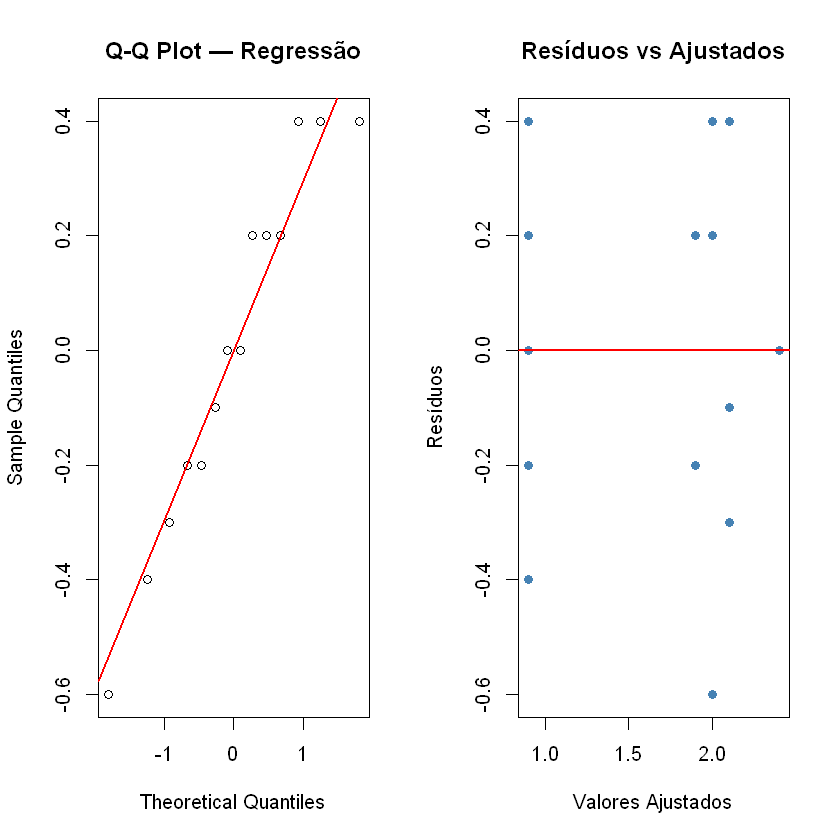

In [74]:
library(lmtest)
res_reg2  <- residuals(mod_reg2)
fit_reg2  <- fitted(mod_reg2)

# Shapiro-Wilk
sw_reg2 <- shapiro.test(res_reg2)

# Breusch-Pagan
bp_reg2 <- bptest(mod_reg2)
cat("Shapiro-Wilk: W =", round(sw_reg2$statistic, 4),
    "| valor-p =", round(sw_reg2$p.value, 4), "\n")

cat("Breusch-Pagan: BP =", round(bp_reg2$statistic, 4),
    "| valor-p =", round(bp_reg2$p.value, 4), "\n")

par(mfrow = c(1, 2))

qqnorm(res_reg2, main = "Q-Q Plot — Regressão")
qqline(res_reg2, col = "red", lwd = 2)

plot(fit_reg2, res_reg2,
     xlab = "Valores Ajustados", ylab = "Resíduos",
     main = "Resíduos vs Ajustados", pch = 19, col = "steelblue")
abline(h = 0, col = "red", lwd = 2)

par(mfrow = c(1, 1))

In [75]:
summary(mod_reg2)


Call:
lm(formula = Taxa ~ Fem + Moderado + Leve + Fem_Mod + Fem_Leve, 
    data = dados2)

Residuals:
   Min     1Q Median     3Q    Max 
  -0.6   -0.2    0.0    0.2    0.4 

Coefficients:
            Estimate Std. Error t value Pr(>|t|)    
(Intercept)   2.0000     0.2327   8.593  2.6e-05 ***
Fem           0.4000     0.4655   0.859   0.4152    
Moderado     -0.1000     0.3680  -0.272   0.7927    
Leve         -1.1000     0.3680  -2.989   0.0174 *  
Fem_Mod      -0.2000     0.5934  -0.337   0.7447    
Fem_Leve     -0.4000     0.5934  -0.674   0.5192    
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Residual standard error: 0.4031 on 8 degrees of freedom
Multiple R-squared:  0.7749,	Adjusted R-squared:  0.6342 
F-statistic: 5.507 on 5 and 8 DF,  p-value: 0.01722


Note que no teste F global valor-p deu 0.017, que é pequeno e $H_0: \boldsymbol{\beta} = 0$ é rejeitada

#### Interpretação dos coeficientes

| Coeficiente | Parâmetro | Significado |
|-------------|-----------|-------------|
| `(Intercept)` | $\mu$ | Média de Masculino–Severo |
| `Fem` | $\alpha_2$ | Diferença Feminino − Masculino no grau Severo |
| `Moderado` | $\beta_2$ | Diferença Moderado − Severo para Masculino |
| `Leve` | $\beta_3$ | Diferença Leve − Severo para Masculino |
| `Fem_Mod` | $\gamma_{22}$ | Quanto a diferença Moderado − Severo muda para Feminino |
| `Fem_Leve` | $\gamma_{23}$ | Quanto a diferença Leve − Severo muda para Feminino |

As respostas preditas de cada tratamento pelo modelo são:

$$\hat{Y}_{ij} = \hat{\mu} + \hat{\alpha}_i + \hat{\beta}_j + \hat{\gamma}_{ij}$$

Nesse caso seria igual a média amostral de cada tratamento.

In [76]:
# Tabela de novas observações para predição (uma por cela)
grid_pred <- data.frame(
  Sexo     = factor(c("Masculino","Masculino","Masculino",
                       "Feminino","Feminino","Feminino"),
                    levels = c("Masculino","Feminino")),
  Grau     = factor(c("Severo","Moderado","Leve",
                       "Severo","Moderado","Leve"),
                    levels = c("Severo","Moderado","Leve")),
  Fem      = c(0,0,0,1,1,1),
  Moderado = c(0,1,0,0,1,0),
  Leve     = c(0,0,1,0,0,1),
  Fem_Mod  = c(0,0,0,0,1,0),
  Fem_Leve = c(0,0,0,0,0,1)
)

grid_pred$Media_predita <- predict(mod_reg2, newdata = grid_pred)

# Médias observadas por cela (para comparação)
grid_pred$Media_obs <- tapply(dados2$Taxa,list(dados2$Sexo, dados2$Grau),
mean)[cbind(as.character(grid_pred$Sexo),as.character(grid_pred$Grau))]

print(grid_pred[, c("Sexo","Grau","Media_obs","Media_predita")])

       Sexo     Grau Media_obs Media_predita
1 Masculino   Severo       2.0           2.0
2 Masculino Moderado       1.9           1.9
3 Masculino     Leve       0.9           0.9
4  Feminino   Severo       2.4           2.4
5  Feminino Moderado       2.1           2.1
6  Feminino     Leve       0.9           0.9


### 2.2 Tabela ANOVA do modelo de regressão

Para dados desbalanceados, usamos novamente o **Tipo III** via `car::Anova()`do R.

In [77]:
library(car)

cat("\n── ANOVA Tipo III (marginal) — car::Anova:\n")
Anova(mod_reg2, type = "III")


── ANOVA Tipo III (marginal) — car::Anova:


,Sum Sq,Df,F value,Pr(>F)
,<dbl>,<dbl>,<dbl>,<dbl>
(Intercept),12.00000000,1,73.84615385,2.599882e-05
Fem,0.12000000,1,0.73846154,4.151604e-01
Moderado,0.01200000,1,0.07384615,7.926981e-01
Leve,1.45200000,1,8.93538462,1.735481e-02
Fem_Mod,0.01846154,1,0.11360947,7.447441e-01
Fem_Leve,0.07384615,1,0.45443787,5.192349e-01
Residuals,1.30000000,8,NA,NA


Pelo resultado, pode-se perceber que o grau de desenvolvimento parece significativo (valor-p de "Leve" é pequeno); Além disso, o sexo e as interações não parecem ter muita significância (valores-p acima de 5%).

Iremos comparar modelo sem interação com o modelo sem grau e sem interação.

In [89]:
mod_final_sem_interacao <- lm(Taxa ~ Sexo + Grau, data = dados2)
Anova(mod_final_sem_interacao, type = "III")

,Sum Sq,Df,F value,Pr(>F)
,<dbl>,<dbl>,<dbl>,<dbl>
(Intercept),11.58857143,1,84.254258,3.465292e-06
Sexo,0.09257143,1,0.673037,4.311159e-01
Grau,4.39600000,2,15.980474,7.687296e-04
Residuals,1.37542857,10,NA,NA


In [93]:
mod_final_sem_grau <- lm(Taxa ~ Fem, data = dados2)
anova(mod_sem_grau,mod_final_sem_interacao)

,Res.Df,RSS,Df,Sum of Sq,F,Pr(>F)
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,12,5.771429,NA,NA,NA,NA
2,10,1.375429,2,4.396,15.98047,0.0007687296


In [94]:
mod_final_sem_sexo <- lm(Taxa ~ Grau, data = dados2)
anova(mod_final_sem_sexo,mod_final_sem_interacao)

,Res.Df,RSS,Df,Sum of Sq,F,Pr(>F)
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,11,1.468000,NA,NA,NA,NA
2,10,1.375429,1,0.09257143,0.673037,0.4311159


### 2.3 Conclusão

A eficiência do hormônio de crecimento sintético é mais influenciada pelo grau de desenvolvimento ósseo da criança; Não há evidencias de que o sexo e as interações entre sexo e grau influenciam na eficiência.